In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import os

_, name = os.path.split(os.getcwd())
if name=="notebooks":
    os.chdir("../.")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import seaborn as sns

In [4]:
import os
# os.environ["HTTPS_PROXY"]=""
# os.environ["https_proxy"]=""

In [5]:
import wandb

api = wandb.Api()
runs = api.runs("itsc2026")

# Get histories for all runs with specific metrics
# histories = runs.histories(format="pandas")
all_results = pl.DataFrame({**run.config, **run.summary} for run in runs).with_columns(
    (pl.col._timestamp * 1000).cast(pl.Datetime("ms"))
)
all_results.columns

['data',
 'name',
 'seed',
 'model',
 'kalman',
 'fourdvar',
 'dx_meters',
 'dt_seconds',
 '_runtime',
 '_step',
 '_timestamp',
 '_wandb',
 'rmse',
 'flow']

# Main sweep

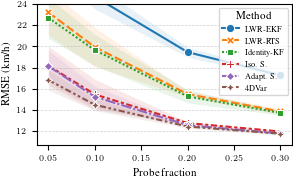

In [ ]:
# experiment_keys = ["name", "model", "probe_fraction"]
from traffic_models.plot.utils import rcparams

experiments = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "itsc_v3"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .rename(dict(name="sweep_name"))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("data").rename({col: f"data.{col}" for col in all_results["data"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.model.replace({"Identity-EKF":"Identity-KF", "ASM":"Adapt. S.", "isotropic-smoothing":"Iso. S."}),
        # pl.col.data.struct.field("name").alias("dataset"),
        pl.col.data.struct.field("probe_fraction"),
        pl.col.data.struct.field("boundary_fraction"),
        pl.col.rmse,
        pl.col.seed,
    )
    .filter(pl.col.seed<10) # i did 11 seeds by mistake
    # .filter(pl.col.boundary_fraction==1.0)
    .remove(pl.col.probe_fraction>0.3)
    # .remove(model="LWR-EKF")
)
# agg_results = (
#     experiments
#     .pivot(
#     index=["model"],
#     on=["probe_fraction"],
#     values="rmse",
#     aggregate_function=
#     #   pl.len(),
#      "$"+pl.element().mean().cast(pl.Utf8).str.head(4)+r"\pm"+pl.element().std().cast(pl.Utf8).str.head(4)+"$",
#     )
#     .transpose(include_header=True)
#     .sort("column")
#     .transpose(include_header=False)
#     # .sort("column")
# )
# agg_results
# print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))
plt.rcParams.update(rcparams(ieee=True, columns=1))
ax: plt.Axes = sns.lineplot(
    data=experiments.sort(by=["probe_fraction", "rmse"], descending=[False, True]).to_pandas(),
    x="probe_fraction",
    y="rmse",
    hue="model",
    style="model",
    markers=True,
    # dashes=False,
    errorbar="sd",
    err_kws={"linewidth": 0, "alpha": 0.1}
)
plt.legend(title="Method")
plt.xlabel("Probe fraction")
plt.ylabel("RMSE (km/h)");
_grid: None = ax.grid(axis="y", which="major", linestyle="--", linewidth=0.5, alpha=0.6)
plt.ylim(top=24)
# plt.savefig("output_plots/itsc/boundary_sweep_rmse_v2.pdf", bbox_inches="tight")
# ax.set_yscale("log")
# ax.set_xscale("log")
# px.line(
#     tab_results #.group_by(["model", "probe_fraction"]).agg(pl.col("rmse").mean())
#     .sort("probe_fraction"),
#     x="probe_fraction",
#     y="rmse",
#     color="model",
#     log_y=True,
#     # markers=True,
# )

In [7]:
(
    experiments
    .pivot(
    index=["model"],
    on=["probe_fraction"],
    values="rmse",
    aggregate_function=
      pl.len(),
    )
    # .sort("column")
)

model,0.05,0.1,0.2,0.3
str,u32,u32,u32,u32
"""4DVar""",10,10,10,10
"""Adapt. S.""",10,10,10,10
"""Iso. S.""",10,10,10,10
"""Identity-KF""",10,10,10,10
"""LWR-EKF""",10,10,10,10
"""LWR-RTS""",10,10,10,10


## Ablation sweep

/var/tmp/ipykernel_1243751/286460920.py:79: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.stripplot(


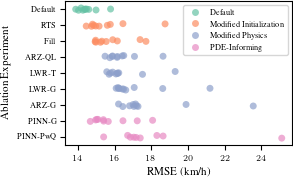

In [6]:
# experiment_keys = ["name", "model", "probe_fraction"]
from traffic_models.plot.utils import rcparams


ablations = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "itsc_ablation_v2" or run.config.get("name") == "itsc_v2"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("fourdvar").rename({col: f"fourdvar.{col}" for col in all_results["fourdvar"].struct.fields})
    .select(
        pl.col.model.replace({"Identity-EKF": "Identity-KF"}),
        # pl.col.data.struct.field("name").alias("dataset"),
        pl.col.data.struct.field("probe_fraction"),
        pl.col.fourdvar.struct.field("fundamental_diagram"),
        pl.col.fourdvar.struct.field("init"),
        pl.col.fourdvar.struct.field("solver"),
        pl.col.fourdvar.struct.field("velocity_model_variance"),
        pl.col.fourdvar.struct.field("learn_flow"),
        pl.col.flow.struct.field("flux_function").struct.field("v_max"),
        pl.col.data.struct.field("ramps"),
        pl.col.rmse,
        pl.col.seed,
    )
    .remove(solver="lax_friedrichs") # not working
    .filter(pl.col.ramps)
    .remove((pl.col.init=="rts") & (pl.col.velocity_model_variance==0.01)) # suboptimal
    .remove((pl.col.init=="forward_fill") & (pl.col.velocity_model_variance==0.01)) # suboptimal
    .remove((pl.col.fundamental_diagram=="ARZGreenshields") & ~(pl.col.learn_flow)) # suboptimal
    .remove((pl.col.fundamental_diagram=="ARZQuadraticLinear") & (pl.col.learn_flow)) # suboptimal
    .remove((pl.col.fundamental_diagram=="ARZGreenshields") & (pl.col.v_max!=30)) 
    .filter((pl.col.model=="4DVar")|(pl.col.model=="PINN"))
    .filter(probe_fraction=0.1)
    .filter(pl.col.seed < 10)  # i did 11 seeds by mistake
    .filter(pl.col.init!="naive_rollout") # not needed
    # .filter(pl.col.velocity_model_variance==2.0)
)
# print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))
plt.rcParams.update(rcparams(ieee=True, columns=1))
plot_data = (ablations.with_columns(
        ablation=pl.concat_str(["model", "fundamental_diagram", "solver", "init"], separator="-")
    .replace({
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "Default",
        "4DVar-ARZPiecewiseQuadratic-lax_friedrichs-naive_smoothing": "LaxF",
        "4DVar-ARZGreenshields-rusanov-naive_smoothing": "ARZ-G",
        "4DVar-ARZQuadraticLinear-rusanov-naive_smoothing": "ARZ-QL",
        "4DVar-LWRTriangular-godunov-naive_smoothing": "LWR-T",
        "4DVar-LWRGreenshields-godunov-naive_smoothing": "LWR-G",
        "4DVar-ARZPiecewiseQuadratic-rusanov-rts": "RTS",
        "4DVar-ARZPiecewiseQuadratic-rusanov-forward_fill": "Fill",
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_rollout": "Rollout",
        "PINN-ARZGreenshields-rusanov-naive_smoothing": "PINN-G",
        "PINN-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "PINN-PwQ",
    }),
        change=pl.concat_str(["model", "fundamental_diagram", "solver", "init"], separator="-")
    .replace({
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "Default",
        "4DVar-ARZPiecewiseQuadratic-lax_friedrichs-naive_smoothing": "Modified Solver",
        "4DVar-ARZGreenshields-rusanov-naive_smoothing": "Modified Physics",
        "4DVar-ARZQuadraticLinear-rusanov-naive_smoothing": "Modified Physics",
        "4DVar-LWRTriangular-godunov-naive_smoothing": "Modified Physics",
        "4DVar-LWRGreenshields-godunov-naive_smoothing": "Modified Physics",
        "4DVar-ARZPiecewiseQuadratic-rusanov-rts": "Modified Initialization",
        "4DVar-ARZPiecewiseQuadratic-rusanov-forward_fill": "Modified Initialization",
        "4DVar-ARZPiecewiseQuadratic-rusanov-naive_rollout": "Modified Initialization",
        "PINN-ARZGreenshields-rusanov-naive_smoothing": "PDE-Informing",
        "PINN-ARZPiecewiseQuadratic-rusanov-naive_smoothing": "PDE-Informing",
    })
    )
    .with_columns(change=pl.when(~pl.col.ramps).then(pl.lit("Modified Boundaries")).otherwise(pl.col.change))
    .with_columns(ablation=pl.when(~pl.col.ramps).then(pl.lit("No ramps")).otherwise(pl.col.ablation))
    .sort(pl.col.change,pl.col.rmse.mean().over("ablation"),)
    .remove(pl.col.rmse>30)
)
ax = sns.stripplot(
    data=plot_data,
    y="ablation",
    x="rmse",
    hue="change",
    alpha=0.7,
    # orient="h",
    # errorbar="ci",
    # err_kws={"linewidth": 1.0},
    # capsize=0.2,
    palette=sns.color_palette("Set2", as_cmap=False)
)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',)
plt.legend()
plt.ylabel("Ablation Experiment")
plt.xlabel("RMSE (km/h)")
# plt.xlim(left=10)
plt.savefig(f"output_plots/itsc/ablation_sweep_rmse_v2.pdf", bbox_inches="tight")
# ax.set_yscale("log")
# px.line(
#     tab_results #.group_by(["model", "probe_fraction"]).agg(pl.col("rmse").mean())
#     .sort("probe_fraction"),
#     x="probe_fraction",
#     y="rmse",
#     color="model",
#     log_y=True,
#     # markers=True,
# )

In [26]:
pl.DataFrame(
    {**run.config, **run.summary}
    for run in runs
    if run.config.get("name") == "itsc_ablation_v2"
    or run.config.get("name") == "itsc_v2"
).with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms"))).filter(
    pl.col.fourdvar.struct.field("fundamental_diagram") != "ARZPiecewiseQuadratic"
).filter(seed=1)

data,flow,name,seed,model,kalman,fourdvar,dx_meters,dt_seconds,_runtime,_step,_timestamp,_wandb,rmse
struct[12],struct[8],str,i64,str,struct[2],struct[8],i64,i64,i64,i64,datetime[ms],object,f64
"{""mobile-century"",""data/mobilecentury/NB_veh_files"",[1, 2, … 8],true,true,32000,43000,34000,1600,true,0.1,1}","{null,null,null,null,null,null,5,{null,null,null,25,0.15,null}}","""itsc_ablation_v2""",1,"""4DVar""","{false,0.1}","{""naive_smoothing"",""rusanov"",500,1,true,1,""ARZGreenshields"",0.01}",200,5,0,0,2026-03-01 04:18:34.896,{'runtime': 0},24.901938
"{""mobile-century"",""data/mobilecentury/NB_veh_files"",[1, 2, … 8],true,true,32000,43000,34000,1600,true,0.1,1}","{null,null,null,null,null,null,5,{22,null,0.022,29,0.094,3}}","""itsc_ablation_v2""",1,"""4DVar""","{false,0.1}","{""naive_smoothing"",""rusanov"",500,1,true,1,""ARZQuadraticLinear"",0.01}",200,5,0,0,2026-03-01 04:24:06.530,{'runtime': 0},22.895892
"{""mobile-century"",""data/mobilecentury/NB_veh_files"",[1, 2, … 8],true,true,32000,43000,34000,1600,true,0.1,1}","{null,0.047,29.05,0.094,2,null,null,null}","""itsc_ablation_v2""",1,"""4DVar""","{false,0.1}","{""naive_smoothing"",""godunov"",500,1,true,1,""LWRGreenshields"",0.01}",200,5,0,0,2026-03-01 04:36:57.278,{'runtime': 0},21.20323


In [50]:
plot_data.group_by("ablation").agg(pl.len(), pl.col.rmse.mean(), pl.col.rmse.std().alias("rmse_std"))

ablation,len,rmse,rmse_std
str,u32,f64,f64
"""RTS""",10,15.550263,1.271649
"""Default""",10,14.488581,0.545978
"""ARZ-QL""",10,16.386651,0.91137
"""LWR-T""",10,16.434921,1.143516
"""LaxF""",10,22.769888,0.540869
"""ARZ-G""",10,20.165525,2.036608
"""Fill""",10,15.805571,1.004166
"""LWR-G""",10,17.113646,1.620008


/var/tmp/ipykernel_716422/2994614442.py:1: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.stripplot(


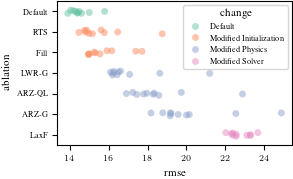

In [28]:
ax = sns.stripplot(
    data=plot_data,
    y="ablation",
    x="rmse",
    hue="change",
    alpha=0.5,
    # orient="h",
    # errorbar="ci",
    # err_kws={"linewidth": 1.0},
    # capsize=0.2,
    palette=sns.color_palette("Set2", as_cmap=False)
)

In [10]:
(
plot_data.group_by("ablation").agg(pl.len())
)

ablation,len
str,u32
"""Fill""",20
"""ARZ-G""",10
"""LWR-G""",10
"""LaxF""",10
"""Default""",10
"""RTS""",20
"""ARZ-QL""",10


/var/tmp/ipykernel_8564/3054876080.py:30: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  ax: plt.Axes = sns.lineplot(


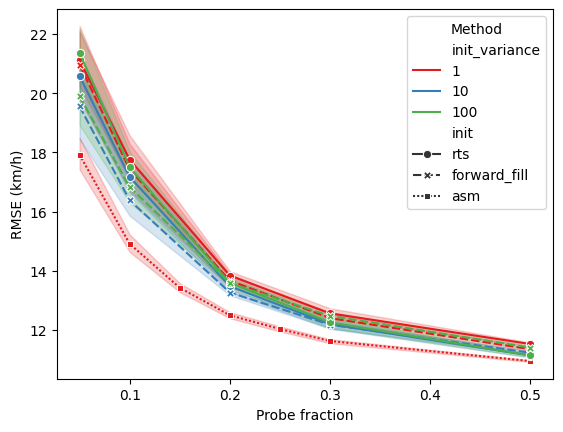

In [ ]:
# experiment_keys = ["name", "model", "probe_fraction"]
from traffic_models.plot.utils import rcparams

init_studies = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == f"itsc_init_cost" or run.config.get("name") == f"itsc_boundary"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("fourdvar").rename({col: f"fourdvar.{col}" for col in all_results["fourdvar"].struct.fields})
    .filter(pl.col.model=="4DVar")
    .select(
        pl.col.data.struct.field("probe_fraction"),
        pl.col.fourdvar.struct.field("init"),
        pl.col.fourdvar.struct.field("init_variance"),
        pl.col.rmse,
        pl.col.seed,
    )
    .filter(pl.col.seed < 10)  # i did 11 seeds by mistake
    .filter(pl.col.init!="naive_rollout") # not needed
    .remove(pl.col.probe_fraction>0.5)
    # .filter(pl.col.velocity_model_variance==2.0)
)

plt.rcParams.update(rcparams(ieee=True, columns=1))
plt.rcdefaults()
ax: plt.Axes = sns.lineplot(
    data=init_studies.sort(by=["probe_fraction", "rmse"], descending=[False, True]),
    x="probe_fraction",
    y="rmse",
    hue="init_variance",
    style="init",
    markers=True,
    palette=sns.color_palette("Set1", as_cmap=False),
    # dashes=False,
)
plt.legend(title="Method")
plt.xlabel("Probe fraction")
plt.ylabel("RMSE (km/h)");
plt.savefig(f"output_plots/itsc/init_sweep_rmse{'_congestion' if congestion else ''}.pdf", bbox_inches="tight")

# deltaXdot sweep

In [ ]:
experiment_keys = ["dataset", "model", "probe_fraction"]
tab_results = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "deltaxdot_ekf"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.model,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.kalman.struct.field("velocity_model_variance"),
        pl.col.mse,
        pl.col.seed,
    )
    .filter(pl.col.seed<10) # i did 11 seeds by mistake
    # .filter(pl.col.velocity_model_variance==2.0)
)
agg_results = (
    tab_results
    # .group_by("seed",*experiment_keys)
    # .agg(pl.col.mse.mean().alias("mse"))
    .pivot(
    index=["model"],
    on=["dataset", "probe_fraction"],
    values="mse",
    aggregate_function= # pl.len(),
     "$"+pl.element().mean().cast(pl.Utf8).str.head(4)+r"\pm"+pl.element().std().cast(pl.Utf8).str.head(4)+"$",
    )
    # .transpose(include_header=True)
    # .sort("column")
)
agg_results
# print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))

In [ ]:
px.line(
    tab_results
    .group_by(*experiment_keys, "velocity_model_variance")
    .agg(pl.col.mse.min().alias("mse"))
    # .filter(dataset="us-101", probe_fraction=0.02)
    .sort([*experiment_keys, "velocity_model_variance"])
    ,
    x="velocity_model_variance",
    log_x=True,
    y="mse",
    facet_row="dataset",
    facet_col="probe_fraction",
    color="model",
    title="Sweep over Kalman process variance",
    markers="x",
    # color_discrete_sequence=px.colors.sequential.Viridis
)

# Xdot vs v EKF sweep

In [ ]:
experiment_keys = ["dataset", "model", "probe_fraction"]
tab_results = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "xdot_ekf"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.model,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.mse,
        pl.col.seed,
    )
)
agg_results = (
    tab_results
    .pivot(
    index=["dataset", "probe_fraction"],
    on=["model"],
    values="mse",
    aggregate_function=
     "$"+pl.element().mean().cast(pl.Utf8).str.head(4)+r"\pm"+pl.element().std().cast(pl.Utf8).str.head(4)+"$",
    )
    .transpose(include_header=True)
    .sort("column")
)
agg_results
# print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))

In [ ]:
experiment_keys = ["dataset", "model", "probe_fraction"]
tab_results = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "paper_table_v2"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.model,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.fundamental_diagram,
        pl.col.kalman.struct.field("desroziers"),
        pl.col.mse,
        pl.col.seed,
    )
)
agg_results = (
    tab_results
    .filter((pl.col.model=="EKF") | (pl.col.fundamental_diagram=="Triangular") )
    .filter(~((pl.col.model=="NaivePhysics") & pl.col.desroziers))
    .pivot(
    index=["dataset", "probe_fraction"],
    on=["model","fundamental_diagram", "desroziers"],
    values="mse",
    aggregate_function=
     "$"+pl.element().mean().cast(pl.Utf8).str.head(4)+r"\pm"+pl.element().std().cast(pl.Utf8).str.head(4)+"$",
    )
    .rename(
        {
        '{"EKF","Identity",true}': "0. Zero",
        '{"EKF","Greenshields",true}': "1. Greenshields",
        '{"EKF","Triangular",true}': "2. Triangular",
        '{"NaivePhysics","Triangular",false}': r"3. Triang. ($\mathbf{K}=1/2$)",
        '{"EKF","Triangular",false}': "4. Triang. (w/o Desr.)",
        }
    )
    .transpose(include_header=True)
    .sort("column")
)
agg_results
print(agg_results.to_pandas().to_latex(index=False).replace(r"\pm0.", r"\pm."))

In [ ]:
px.histogram(
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "paper_table"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    .with_columns(
        pl.col.kalman.struct.field("velocity_model_variance"),
        pl.col.ngsim.struct.field("dataset"),
        pl.col.kalman.struct.field("desroziers"),
        )
    .filter(pl.col.desroziers)
    .with_columns(pl.col.velocity_model_variance),
    "velocity_model_variance",
    color="dataset"
)

# Probe penetration and variance sweep

In [ ]:
experiment_keys = ["dataset", "model", "probe_fraction"]
pf_results = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "probe_fraction_v2" #or run.config.get("name") == "probe_fraction"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.name,
        pl.col.model,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.kalman.struct.field("velocity_model_variance"),
        pl.col.kalman.struct.field("desroziers"),
        pl.col.mse,
        pl.col.neg_log_lik,
        pl.col.seed,
    )
)
pf_results

In [ ]:
from matplotlib.ticker import ScalarFormatter

from traffic_models.plot.utils import rcparams

plt.rcParams.update(rcparams(fraction=0.5, subplots=(1,1)))
GOLDEN_RATIO = (1 + 5 ** 0.5) / 2
# plt.rcdefaults()
plot_table = (pf_results
    # .filter(pl.col.velocity_model_variance == 0.1)
    # .filter(pl.col.seed==0)
    .filter(pl.col.dataset=="us-101")
    .with_columns(pl.col.probe_fraction*100)  # Convert to percentage
    .with_columns(pl.col.model.replace("NaivePhysics", "Naive assim."))
    .sort(by=experiment_keys, descending=[False, True, True]))
g = sns.relplot(
    data=plot_table.to_pandas(),
    x="probe_fraction",
    y="mse",
    hue="model",
    # col="dataset",
    kind="line",
    facet_kws={'sharey': False, 'sharex': True},
    markers=True,
    errorbar="sd",  # Use standard deviation for error bars
    err_style="bars",  # Use bars for error representation
    err_kws={"capsize": 3},  # Add caps to error bars
    aspect=GOLDEN_RATIO,
)

g.set_axis_labels(r"Probe Penetration (\%)", "MSE")
# # Set log scale for x-axis
plt.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3, axis='y')
g._legend.set_title("method")
for ax in g.axes.flat:
    ax.set_xscale("symlog")
    ax.set_xlim(-0.1, 100)
    ax.xaxis.set_major_formatter(ScalarFormatter())  # Use decimal formatting
    ax.ticklabel_format(style='plain', axis='x')  # Ensure plain formatting
# g.figure.set_size_inches(5.5, 5.5 / GOLDEN_RATIO / 2)
g.figure.set_size_inches(5.5/2, 5.5 / GOLDEN_RATIO/2)
plt.savefig("output_plots/naive_assim.pdf",format="pdf",bbox_inches='tight');

In [ ]:
pf_results_compare = (
    pl.DataFrame(
        {**run.config, **run.summary}
        for run in runs
        if run.config.get("name") == "probe_fraction_v2" or run.config.get("name") == "probe_fraction"
    )
    .with_columns((pl.col._timestamp * 1000).cast(pl.Datetime("ms")))
    # .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
    # .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
    # .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .select(
        pl.col.name,
        pl.col.model,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.kalman.struct.field("velocity_model_variance"),
        pl.col.mse,
        pl.col.neg_log_lik,
        pl.col.seed,
    )
)

In [ ]:
(pf_results
    # .filter(pl.col.velocity_model_variance == 0.1)
    # .filter(pl.col.seed==0)
    .with_columns(pl.col.model.replace("NaivePhysics", "Naive assim."))
    .filter(pl.col.dataset=="us-101")
    .group_by("model","probe_fraction","dataset")
    .agg(pl.col.mse.mean(),error=pl.col.mse.std())
    .pivot(values=["mse"],index=["model"],on="probe_fraction")
)

If a good model is available, Kalman is not strictly necessary.
However, it seems that it shines when physical parameters are not good.
! We should use the same dataset and different parameters instead

In [ ]:
px.line(
    pf_results
    .filter(pl.col.seed==0) # only this seed was tested for all variances
    .filter(pl.col.velocity_model_variance<1)
    .with_columns(
        pl.col.mse.mean().over(experiment_keys), # aggregate over hyperparam
        mse_std=pl.col.mse.std().over(experiment_keys) # aggregate over hyperparam
    ).unique().sort(by=experiment_keys),
    x="probe_fraction",
    error_y="mse_std",
    log_x=True,
    y="mse",
    facet_row="dataset",
    color="model",
    title="Performance by penetration rate, deviation over model_variance",
    markers="x",
)

In [ ]:
px.line(
    pf_results
    .filter(pl.col.model == "EKF")
    .filter(seed=0) # only this seed was tested for all variances
    .sort([*experiment_keys, "velocity_model_variance"])
    .filter(pl.col.velocity_model_variance > 0.01),
    x="velocity_model_variance",
    log_x=True,
    y="neg_log_lik",
    facet_row="dataset",
    color="probe_fraction",
    title="Sweep over Kalman process variance (NLL)",
    markers="x",
    color_discrete_sequence=px.colors.sequential.Viridis
)

In [ ]:
px.line(
    pf_results_compare
    .filter(pl.col.model == "EKF")
    .filter(pl.col.dataset=="us-101")
    .filter(seed=0) # only this seed was tested for all variances
    .sort([*experiment_keys, "velocity_model_variance"])
    .filter(pl.col.velocity_model_variance > 0.01)
    .filter(pl.col.probe_fraction < 0.1),
    x="velocity_model_variance",
    log_x=True,
    log_y=True,
    y="mse",
    facet_row="name",
    color="probe_fraction",
    title="Sweep over Kalman process variance (MSE)",
    markers="x",
    color_discrete_sequence=px.colors.sequential.Viridis
)

# Fundamental Diagram sweep

In [ ]:
experiment_keys = ["dataset", "model", "fundamental_diagram", "probe_fraction"]
fd_results = (all_results
# .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
# .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
# .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .filter(pl.col.name=="diagram")   
    .select(
        pl.col.model,
        pl.col.fundamental_diagram,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.mse,
        pl.col.neg_log_lik,
    )
)
fd_results.head()

In [ ]:
px.line(
    fd_results
    .sort(by=experiment_keys)
    # .filter(pl.col.model=="EKF")
    ,
    x="probe_fraction",
    log_x=True,
    log_y=True,
    y="mse",
    facet_row="dataset",
    facet_col="model",
    color="fundamental_diagram",
    title="Performance for various Fundamental Diagrams",
    markers="x",
    color_discrete_sequence=px.colors.qualitative.Plotly[3:]
)

In [ ]:
px.line(
    fd_results
    # .filter(pl.col.model=="EKF")
    # .filter(pl.col.fundamental_diagram=="Identity")
    # .filter(pl.col.dataset=="us-101")
    .sort(by=experiment_keys)
    .rename({"fundamental_diagram":"diagram"})
    ,
    x="probe_fraction",
    log_x=True,
    log_y=True,
    y="mse",
    facet_col="diagram",
    facet_row="dataset",
    color="model",
    title="Performance for various Models",
    markers="x",
    # color_discrete_sequence=px.colors.qualitative.Plotly[3:]
)

# Boundary fraction sweep

In [ ]:
experiment_keys = ["dataset", "model", "probe_fraction", "boundary_fraction"]
bf_results = (all_results
# .unnest("flow").rename({col: f"flow.{col}" for col in df["flow"].struct.fields})
# .unnest("ngsim").rename({col: f"ngsim.{col}" for col in results["ngsim"].struct.fields})
# .unnest("kalman").rename({col: f"kalman.{col}" for col in results["kalman"].struct.fields})
    .filter(pl.col.name=="boundary_fraction")   
    .select(
        pl.col.model,
        pl.col.ngsim.struct.field("dataset"),
        pl.col.ngsim.struct.field("probe_fraction"),
        pl.col.ngsim.struct.field("boundary_fraction"),
        pl.col.mse,
        pl.col.seed,
        pl.col.neg_log_lik,
    )
)
bf_results["seed"].unique()

In [ ]:
px.line(
    bf_results
    .sort(by=experiment_keys)
    # .filter(pl.col.model=="EKF")
    ,
    x="boundary_fraction",
    # log_x=True,
    # log_y=True,
    y="mse",
    facet_row="dataset",
    facet_col="model",
    color="probe_fraction",
    title="Boundary information",
    markers="x",
    color_discrete_sequence=px.colors.sequential.Viridis
)